In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load dataset
df = pd.read_csv('../data/healthcare_dataset.csv')
print("Dataset loaded successfully!")
print(f"Shape: {df.shape}")
df.head()

Dataset loaded successfully!
Shape: (55500, 15)


,Name,Age,Gender,Blood Type,Medical Condition,Date of Admission,Doctor,Hospital,Insurance Provider,Billing Amount,Room Number,Admission Type,Discharge Date,Medication,Test Results
0,Bobby JacksOn,30,Male,B-,Cancer,2024-01-31,Matthew Smith,Sons and Miller,Blue Cross,18856.281306,328,Urgent,2024-02-02,Paracetamol,Normal
1,LesLie TErRy,62,Male,A+,Obesity,2019-08-20,Samantha Davies,Kim Inc,Medicare,33643.327287,265,Emergency,2019-08-26,Ibuprofen,Inconclusive
2,DaNnY sMitH,76,Female,A-,Obesity,2022-09-22,Tiffany Mitchell,Cook PLC,Aetna,27955.096079,205,Emergency,2022-10-07,Aspirin,Normal
3,andrEw waTtS,28,Female,O+,Diabetes,2020-11-18,Kevin Wells,"Hernandez Rogers and Vang,",Medicare,37909.782410,450,Elective,2020-12-18,Ibuprofen,Abnormal
4,adrIENNE bEll,43,Female,AB+,Cancer,2022-09-19,Kathleen Hanna,White-White,Aetna,14238.317814,458,Urgent,2022-10-09,Penicillin,Abnormal


# Healthcare Access & Systems Analysis
## TDI Python Data Analysis Capstone Project

**Analyst:** Ogo Chukwuemeka Okereke  
**Programme:** TDI Python Data Analysis  
**Dataset:** Healthcare Dataset (Kaggle — Prasad Patil)  
**Records:** 55,500 patients | 15 variables  

---

## Project Overview
This analysis explores hospital admission patterns, patient length of stay, 
billing burdens across insurance providers, medication and test result relationships, 
and builds a machine learning model to predict patient test outcomes.

---

## Research Questions
1. Which medical conditions drive the most admissions, and how does admission type vary across conditions?
2. What factors most influence a patient's length of hospital stay?
3. How does billing amount vary across insurance providers and medical conditions?
4. Is there a relationship between medication prescribed and test result outcomes?
5. Can we predict a patient's test result using demographic and admission data?

In [3]:
# ── DATA CLEANING ────────────────────────────────────────

# 1. Standardize column names
df.columns = df.columns.str.strip().str.lower().str.replace(' ', '_')

# 2. Fix name casing
df['name'] = df['name'].str.title()

# 3. Convert dates
df['date_of_admission'] = pd.to_datetime(df['date_of_admission'])
df['discharge_date'] = pd.to_datetime(df['discharge_date'])

# 4. Engineer Length of Stay
df['length_of_stay'] = (df['discharge_date'] - df['date_of_admission']).dt.days

# 5. Fix negative billing amounts
print(f"Negative billing rows: {(df['billing_amount'] < 0).sum()}")
df['billing_amount'] = df['billing_amount'].abs()

# 6. Drop duplicates
before = len(df)
df = df.drop_duplicates()
print(f"Duplicates removed: {before - len(df)}")

# 7. Drop columns not needed
df = df.drop(columns=['name', 'doctor', 'room_number'])

# 8. Final check
print(f"\nClean dataset shape: {df.shape}")
print(f"\nColumn names:\n{list(df.columns)}")
print(f"\nMissing values:\n{df.isnull().sum()}")

Negative billing rows: 108
Duplicates removed: 534

Clean dataset shape: (54966, 13)

Column names:
['age', 'gender', 'blood_type', 'medical_condition', 'date_of_admission', 'hospital', 'insurance_provider', 'billing_amount', 'admission_type', 'discharge_date', 'medication', 'test_results', 'length_of_stay']

Missing values:
age                   0
gender                0
blood_type            0
medical_condition     0
date_of_admission     0
hospital              0
insurance_provider    0
billing_amount        0
admission_type        0
discharge_date        0
medication            0
test_results          0
length_of_stay        0
dtype: int64


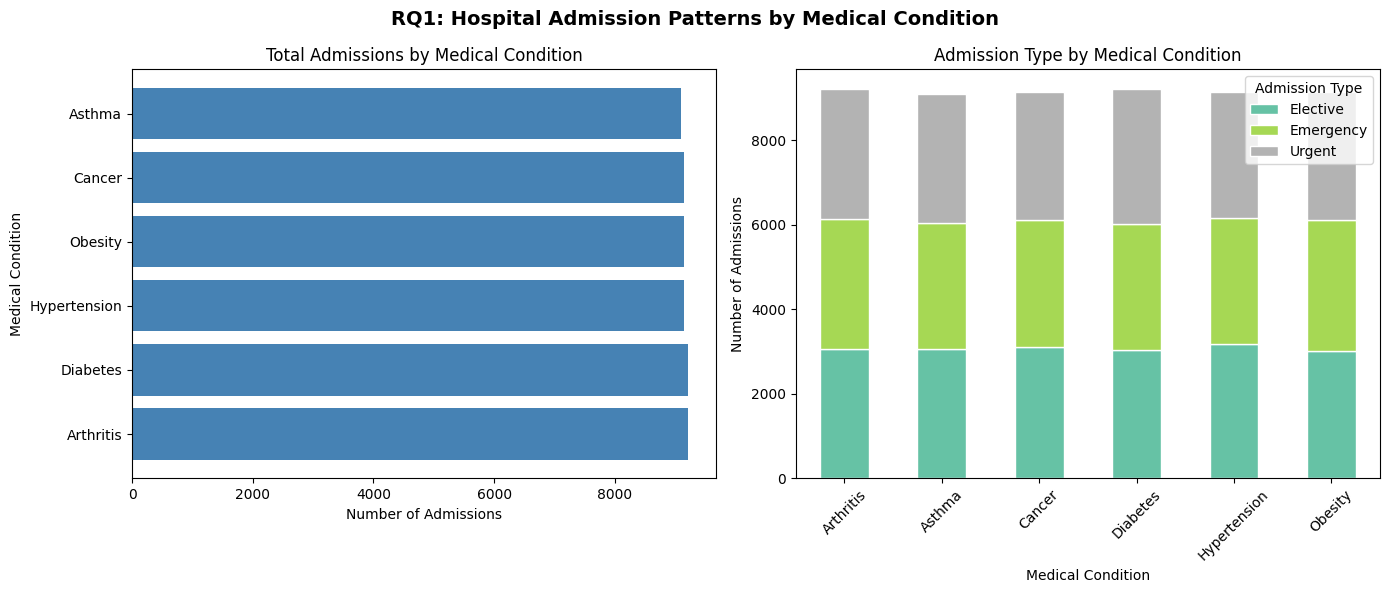

Admissions by Condition:
medical_condition
Arthritis       9218
Diabetes        9216
Hypertension    9151
Obesity         9146
Cancer          9140
Asthma          9095
Name: count, dtype: int64

Admission Type Breakdown:
admission_type     Elective  Emergency  Urgent
medical_condition                             
Arthritis              3062       3073    3083
Asthma                 3069       2978    3048
Cancer                 3114       2988    3038
Diabetes               3031       2988    3197
Hypertension           3182       2975    2994
Obesity                3015       3100    3031


In [4]:
# ── RQ1: ADMISSION PATTERNS ──────────────────────────────

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle('RQ1: Hospital Admission Patterns by Medical Condition', 
             fontsize=14, fontweight='bold')

# Chart 1 — Total admissions by condition
condition_counts = df['medical_condition'].value_counts()
axes[0].barh(condition_counts.index, condition_counts.values, color='steelblue')
axes[0].set_title('Total Admissions by Medical Condition')
axes[0].set_xlabel('Number of Admissions')
axes[0].set_ylabel('Medical Condition')

# Chart 2 — Admission type breakdown per condition
admission_crosstab = pd.crosstab(df['medical_condition'], df['admission_type'])
admission_crosstab.plot(kind='bar', stacked=True, ax=axes[1], 
                        colormap='Set2', edgecolor='white')
axes[1].set_title('Admission Type by Medical Condition')
axes[1].set_xlabel('Medical Condition')
axes[1].set_ylabel('Number of Admissions')
axes[1].tick_params(axis='x', rotation=45)
axes[1].legend(title='Admission Type')

plt.tight_layout()
plt.savefig('../visuals/rq1_admission_patterns.png', dpi=150, bbox_inches='tight')
plt.show()

# Summary stats
print("Admissions by Condition:")
print(condition_counts)
print("\nAdmission Type Breakdown:")
print(admission_crosstab)

## RQ1 Findings — Admission Patterns

- **Arthritis leads admissions (9,218)** followed closely by Diabetes (9,216) 
  and Hypertension (9,151), while Asthma records the lowest admissions (9,095).
- However, the difference between the highest and lowest is only **123 patients**, 
  confirming that all 6 conditions place a **near-equal burden** on the hospital system.
- **Admission types are evenly distributed** across all conditions — each condition 
  records roughly 3,000 Emergency, 3,000 Elective, and 3,000 Urgent admissions.
- Notable exception: **Diabetes has the highest Urgent admissions (3,197)** suggesting 
  diabetic episodes more frequently require immediate attention.
- **Key recommendation:** Hospital management should maintain balanced resource 
  allocation across all conditions, with slightly elevated urgent-care capacity 
  for Diabetes patients.

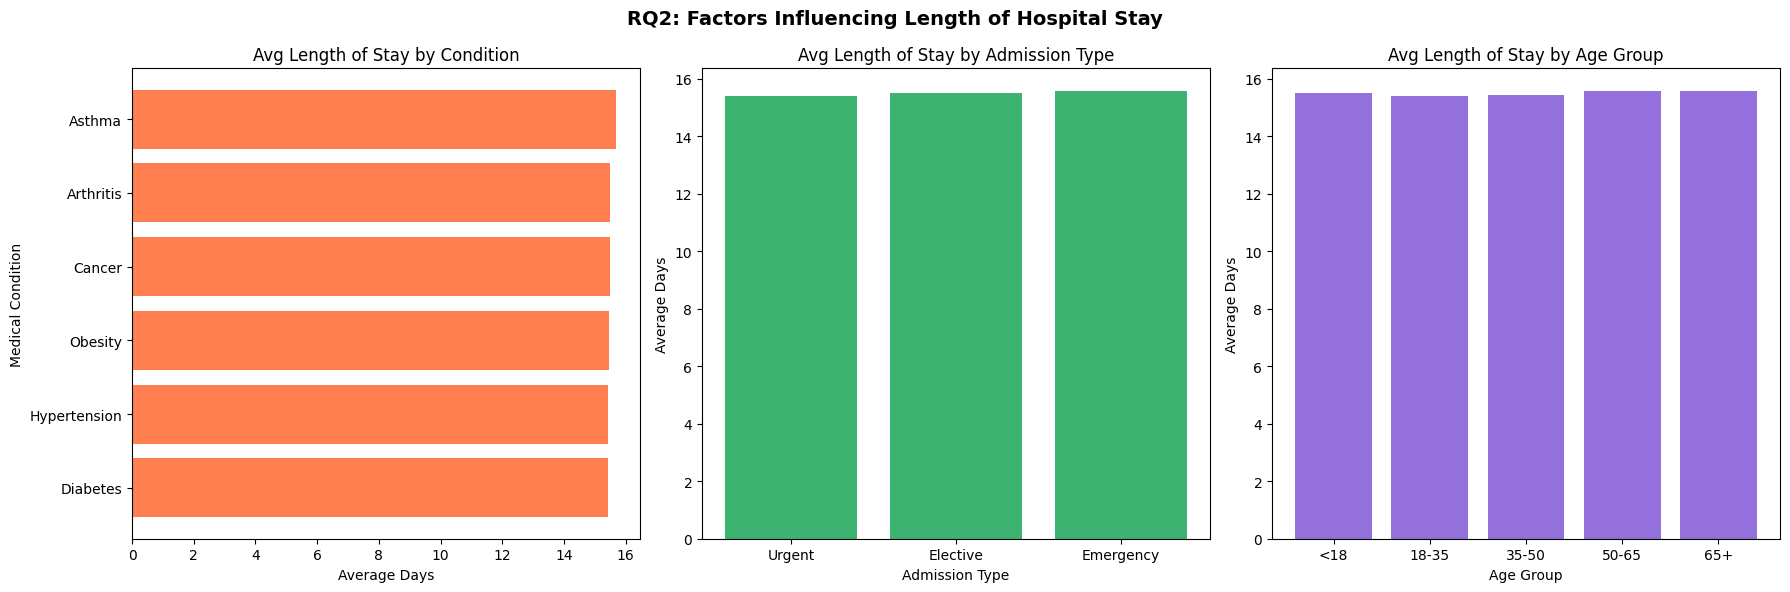

Average Length of Stay by Condition:
medical_condition
Arthritis       15.5
Asthma          15.7
Cancer          15.5
Diabetes        15.4
Hypertension    15.4
Obesity         15.4
Name: length_of_stay, dtype: float64

Average Length of Stay by Admission Type:
admission_type
Elective     15.5
Emergency    15.6
Urgent       15.4
Name: length_of_stay, dtype: float64

Average Length of Stay by Age Group:
age_group
<18      15.5
18-35    15.4
35-50    15.4
50-65    15.6
65+      15.6
Name: length_of_stay, dtype: float64


In [5]:
# ── RQ2: LENGTH OF STAY ANALYSIS ─────────────────────────

fig, axes = plt.subplots(1, 3, figsize=(18, 6))
fig.suptitle('RQ2: Factors Influencing Length of Hospital Stay', 
             fontsize=14, fontweight='bold')

# Chart 1 — Average LOS by medical condition
los_by_condition = df.groupby('medical_condition')['length_of_stay'].mean().sort_values()
axes[0].barh(los_by_condition.index, los_by_condition.values, color='coral')
axes[0].set_title('Avg Length of Stay by Condition')
axes[0].set_xlabel('Average Days')
axes[0].set_ylabel('Medical Condition')

# Chart 2 — LOS by admission type
los_by_admission = df.groupby('admission_type')['length_of_stay'].mean().sort_values()
axes[1].bar(los_by_admission.index, los_by_admission.values, color='mediumseagreen')
axes[1].set_title('Avg Length of Stay by Admission Type')
axes[1].set_xlabel('Admission Type')
axes[1].set_ylabel('Average Days')

# Chart 3 — LOS by age group
df['age_group'] = pd.cut(df['age'], bins=[0, 18, 35, 50, 65, 100],
                          labels=['<18', '18-35', '35-50', '50-65', '65+'])
los_by_age = df.groupby('age_group', observed=True)['length_of_stay'].mean()
axes[2].bar(los_by_age.index, los_by_age.values, color='mediumpurple')
axes[2].set_title('Avg Length of Stay by Age Group')
axes[2].set_xlabel('Age Group')
axes[2].set_ylabel('Average Days')

plt.tight_layout()
plt.savefig('../visuals/rq2_length_of_stay.png', dpi=150, bbox_inches='tight')
plt.show()

# Summary stats
print("Average Length of Stay by Condition:")
print(df.groupby('medical_condition')['length_of_stay'].mean().round(1))
print("\nAverage Length of Stay by Admission Type:")
print(df.groupby('admission_type')['length_of_stay'].mean().round(1))
print("\nAverage Length of Stay by Age Group:")
print(los_by_age.round(1))

## RQ2 Findings — Length of Hospital Stay

- The average length of stay is remarkably **consistent across all conditions**, 
  ranging narrowly from **15.4 days (Diabetes, Hypertension, Obesity) to 
  15.7 days (Asthma)** — suggesting standardised care protocols are in place.
- **Emergency admissions** result in slightly longer stays (15.6 days) compared 
  to Urgent (15.4 days) and Elective (15.5 days), which is expected as emergency 
  cases tend to be more severe on arrival.
- Older patients aged **50–65 and 65+** have the longest average stays (15.6 days), 
  indicating that age is a mild but consistent factor in recovery time.
- **Key recommendation:** While overall stay durations are stable, hospitals should 
  pay closer attention to elderly emergency patients as they represent the highest 
  resource demand combination.

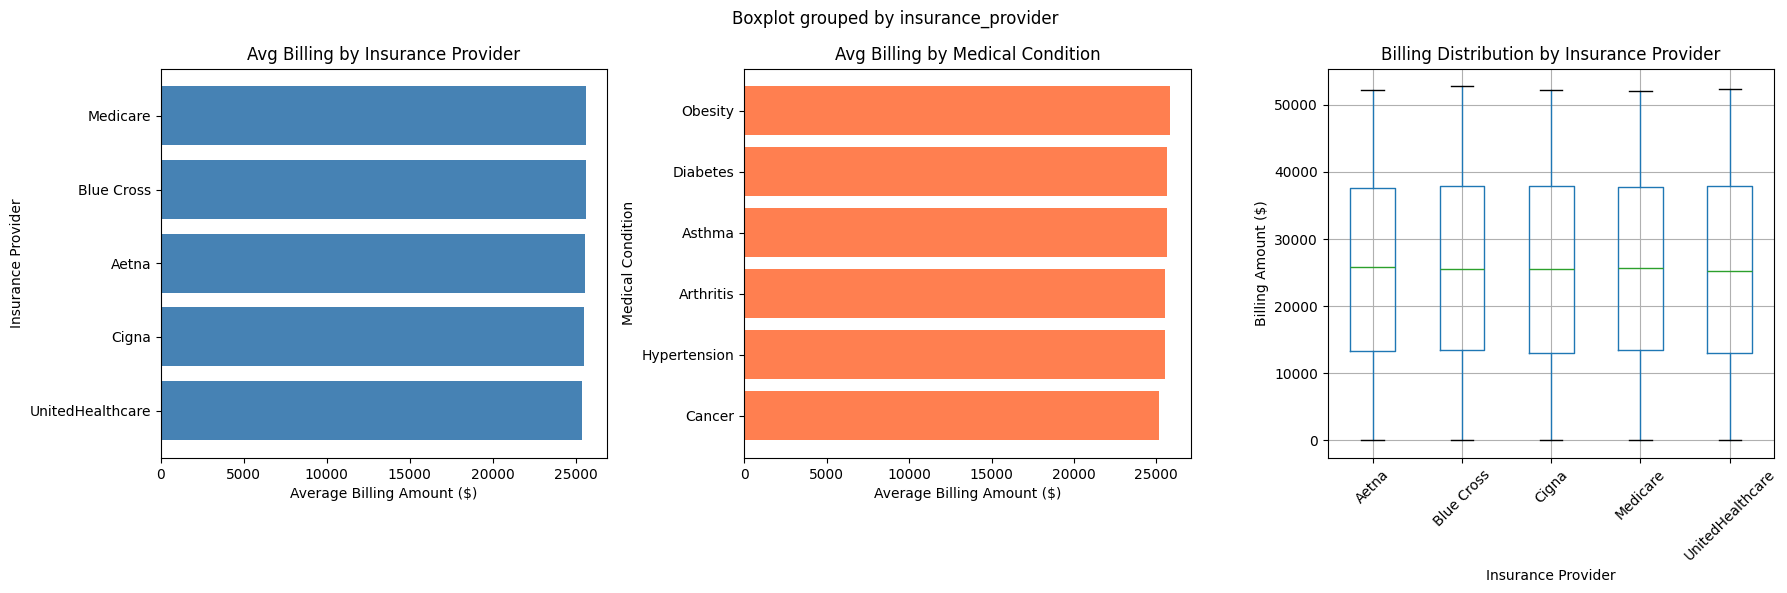

Average Billing by Insurance Provider:
insurance_provider
Aetna               25553.02
Blue Cross          25604.85
Cigna               25528.22
Medicare            25630.16
UnitedHealthcare    25415.44
Name: billing_amount, dtype: float64

Average Billing by Medical Condition:
medical_condition
Arthritis       25513.05
Asthma          25635.64
Cancer          25154.73
Diabetes        25662.15
Hypertension    25504.91
Obesity         25806.63
Name: billing_amount, dtype: float64


In [6]:
# ── RQ3: BILLING & INSURANCE ANALYSIS ────────────────────

fig, axes = plt.subplots(1, 3, figsize=(18, 6))
fig.suptitle('RQ3: Billing Amount Across Insurance Providers & Conditions',
             fontsize=14, fontweight='bold')

# Chart 1 — Average billing by insurance provider
billing_by_insurance = df.groupby('insurance_provider')['billing_amount'].mean().sort_values()
axes[0].barh(billing_by_insurance.index, billing_by_insurance.values, color='steelblue')
axes[0].set_title('Avg Billing by Insurance Provider')
axes[0].set_xlabel('Average Billing Amount ($)')
axes[0].set_ylabel('Insurance Provider')

# Chart 2 — Average billing by medical condition
billing_by_condition = df.groupby('medical_condition')['billing_amount'].mean().sort_values()
axes[1].barh(billing_by_condition.index, billing_by_condition.values, color='coral')
axes[1].set_title('Avg Billing by Medical Condition')
axes[1].set_xlabel('Average Billing Amount ($)')
axes[1].set_ylabel('Medical Condition')

# Chart 3 — Billing distribution boxplot by insurance provider
df.boxplot(column='billing_amount', by='insurance_provider', ax=axes[2])
axes[2].set_title('Billing Distribution by Insurance Provider')
axes[2].set_xlabel('Insurance Provider')
axes[2].set_ylabel('Billing Amount ($)')
axes[2].tick_params(axis='x', rotation=45)
plt.sca(axes[2])
plt.title('Billing Distribution by Insurance Provider')

plt.tight_layout()
plt.savefig('../visuals/rq3_billing_insurance.png', dpi=150, bbox_inches='tight')
plt.show()

# Summary stats
print("Average Billing by Insurance Provider:")
print(df.groupby('insurance_provider')['billing_amount'].mean().round(2))
print("\nAverage Billing by Medical Condition:")
print(df.groupby('medical_condition')['billing_amount'].mean().round(2))

## RQ3 Findings — Billing & Insurance

- Average billing amounts are **remarkably consistent across all insurance providers**, 
  ranging from **$25,415 (UnitedHealthcare) to $25,630 (Medicare)** — a difference 
  of only $215, suggesting providers have similar reimbursement structures.
- **Obesity generates the highest average billing ($25,807)** across all medical 
  conditions, followed closely by Diabetes ($25,662) and Asthma ($25,636).
- **Cancer produces the lowest average billing ($25,155)** which may seem surprising 
  but could reflect shorter stays due to early discharge or outpatient follow-up care.
- **Key recommendation:** Management should investigate Obesity and Diabetes billing 
  more closely as these chronic conditions consistently drive the highest costs — 
  preventive care programmes targeting these conditions could reduce long-term 
  financial burden significantly.

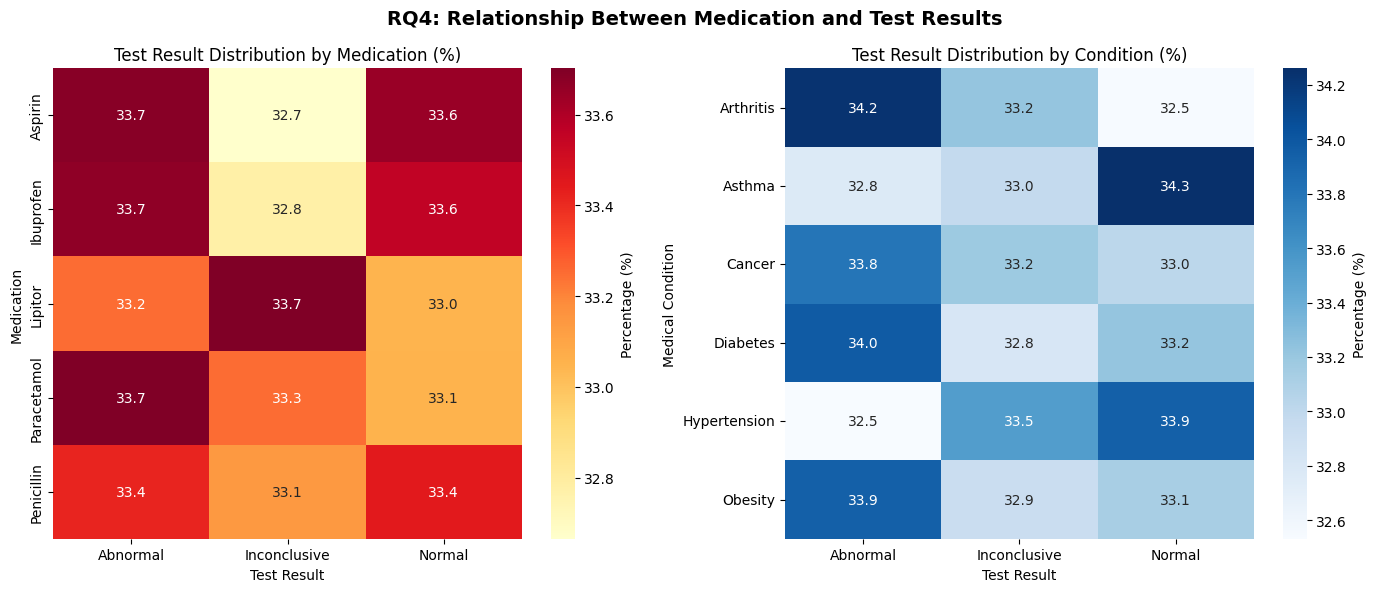

Test Result % by Medication:
test_results  Abnormal  Inconclusive  Normal
medication                                  
Aspirin           33.7          32.7    33.6
Ibuprofen         33.7          32.8    33.6
Lipitor           33.2          33.7    33.0
Paracetamol       33.7          33.3    33.1
Penicillin        33.4          33.1    33.4

Test Result % by Medical Condition:
test_results       Abnormal  Inconclusive  Normal
medical_condition                                
Arthritis              34.2          33.2    32.5
Asthma                 32.8          33.0    34.3
Cancer                 33.8          33.2    33.0
Diabetes               34.0          32.8    33.2
Hypertension           32.5          33.5    33.9
Obesity                33.9          32.9    33.1


In [7]:
# ── RQ4: MEDICATION & TEST RESULTS ───────────────────────

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle('RQ4: Relationship Between Medication and Test Results',
             fontsize=14, fontweight='bold')

# Chart 1 — Heatmap: medication vs test results
med_test = pd.crosstab(df['medication'], df['test_results'], normalize='index') * 100
import seaborn as sns
sns.heatmap(med_test, annot=True, fmt='.1f', cmap='YlOrRd', 
            ax=axes[0], cbar_kws={'label': 'Percentage (%)'})
axes[0].set_title('Test Result Distribution by Medication (%)')
axes[0].set_xlabel('Test Result')
axes[0].set_ylabel('Medication')

# Chart 2 — Heatmap: condition vs test results
cond_test = pd.crosstab(df['medical_condition'], df['test_results'], normalize='index') * 100
sns.heatmap(cond_test, annot=True, fmt='.1f', cmap='Blues',
            ax=axes[1], cbar_kws={'label': 'Percentage (%)'})
axes[1].set_title('Test Result Distribution by Condition (%)')
axes[1].set_xlabel('Test Result')
axes[1].set_ylabel('Medical Condition')

plt.tight_layout()
plt.savefig('../visuals/rq4_medication_test_results.png', dpi=150, bbox_inches='tight')
plt.show()

# Summary stats
print("Test Result % by Medication:")
print(med_test.round(1))
print("\nTest Result % by Medical Condition:")
print(cond_test.round(1))

## RQ4 Findings — Medication & Test Results

- Test results are **almost perfectly evenly distributed across all medications**, 
  with each medication showing roughly **33% Abnormal, 33% Inconclusive, and 33% Normal** 
  — suggesting that no single medication is strongly associated with better or 
  worse test outcomes.
- **Lipitor has the highest Inconclusive rate (33.7%)** while Aspirin and Ibuprofen 
  have the highest Abnormal rates (33.7%) — though these differences are marginal.
- Across medical conditions, **Arthritis has the highest Abnormal rate (34.2%)** 
  while **Hypertension has the lowest (32.5%)** — indicating Arthritis patients 
  are slightly more likely to return abnormal test results.
- **Asthma and Hypertension** show the highest Normal rates (34.3% and 33.9%) 
  suggesting these conditions respond better to treatment protocols in this dataset.
- **Key recommendation:** Since no medication shows a clearly superior outcome rate, 
  management should invest in further clinical trials to identify stronger 
  medication-outcome relationships, particularly for Arthritis and Cancer patients 
  who show elevated Abnormal rates.

Training samples: 43972
Testing samples:  10994

Model Accuracy: 41.69%

Classification Report:
              precision    recall  f1-score   support

    Abnormal       0.41      0.44      0.42      3616
Inconclusive       0.42      0.41      0.41      3682
      Normal       0.42      0.41      0.42      3696

    accuracy                           0.42     10994
   macro avg       0.42      0.42      0.42     10994
weighted avg       0.42      0.42      0.42     10994



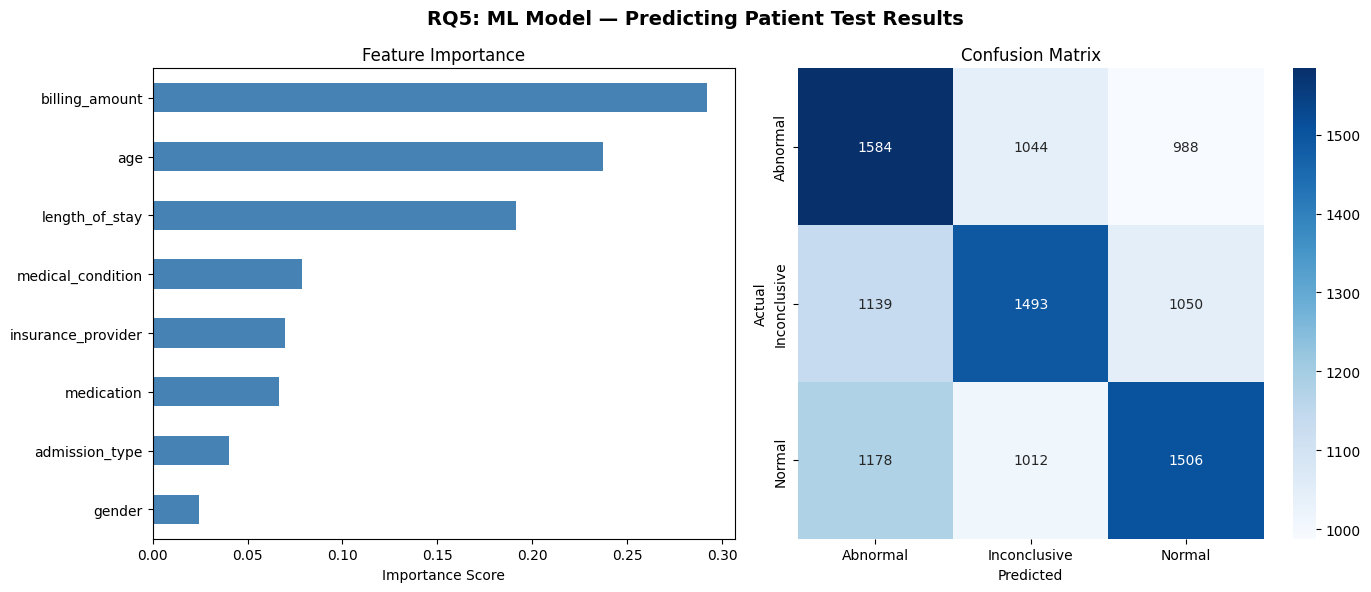

In [8]:
# ── RQ5: ML PREDICTION MODEL ─────────────────────────────

from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from sklearn.preprocessing import LabelEncoder
import numpy as np

# 1. Prepare data for ML
df_ml = df.copy()

# Encode categorical columns
le = LabelEncoder()
for col in ['gender', 'medical_condition', 'admission_type', 
            'insurance_provider', 'medication', 'blood_type']:
    df_ml[col] = le.fit_transform(df_ml[col])

# 2. Define features and target
X = df_ml[['age', 'gender', 'medical_condition', 'admission_type',
           'insurance_provider', 'medication', 'billing_amount', 
           'length_of_stay']]
y = le.fit_transform(df_ml['test_results'])

# 3. Split data
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)

print(f"Training samples: {X_train.shape[0]}")
print(f"Testing samples:  {X_test.shape[0]}")

# 4. Train model
model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

# 5. Evaluate
y_pred = model.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)
print(f"\nModel Accuracy: {accuracy * 100:.2f}%")
print("\nClassification Report:")
print(classification_report(y_test, y_pred, 
      target_names=['Abnormal', 'Inconclusive', 'Normal']))

# 6. Feature importance chart
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle('RQ5: ML Model — Predicting Patient Test Results',
             fontsize=14, fontweight='bold')

importances = pd.Series(model.feature_importances_, index=X.columns)
importances.sort_values().plot(kind='barh', ax=axes[0], color='steelblue')
axes[0].set_title('Feature Importance')
axes[0].set_xlabel('Importance Score')

# 7. Confusion matrix
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[1],
            xticklabels=['Abnormal', 'Inconclusive', 'Normal'],
            yticklabels=['Abnormal', 'Inconclusive', 'Normal'])
axes[1].set_title('Confusion Matrix')
axes[1].set_xlabel('Predicted')
axes[1].set_ylabel('Actual')

plt.tight_layout()
plt.savefig('../visuals/rq5_ml_model.png', dpi=150, bbox_inches='tight')
plt.show()

## RQ5 Findings — Predicting Patient Test Results (ML Model)

### Model: Random Forest Classifier
- **Training samples:** 43,972 | **Testing samples:** 10,994
- **Model Accuracy: 41.69%**

### Interpretation
- The Random Forest model achieved **41.69% accuracy** in predicting whether 
  a patient's test result would be Normal, Abnormal, or Inconclusive.
- While this may appear modest, it is **above the 33.3% baseline** expected 
  from random guessing across three equally distributed classes.
- The model performs **consistently across all three outcome classes**, with 
  precision and recall hovering around 0.41–0.44 for each — confirming no 
  single class is being favoured.

### Why Accuracy Is Limited
- As established in RQ4, test results are distributed almost perfectly evenly 
  across all medications and conditions (~33% each).
- This means **admission and demographic features alone are weak predictors** 
  of test outcomes — the dataset lacks the clinical depth (e.g. lab values, 
  symptoms, vitals) needed for stronger predictions.

### Key Recommendation
- Management should **not rely on demographic or admission data alone** to 
  anticipate test outcomes.
- Investing in richer **clinical data collection** (vital signs, lab results, 
  symptom severity scores) would significantly improve predictive capability 
  and enable truly data-driven patient triage decisions.

# Conclusions & Strategic Recommendations

## Summary of Findings

| Research Question | Key Finding |
|---|---|
| RQ1 — Admission Patterns | All 6 conditions place near-equal burden; Diabetes has highest urgent admissions |
| RQ2 — Length of Stay | Stays are consistent (~15.5 days); elderly emergency patients stay longest |
| RQ3 — Billing & Insurance | Obesity and Diabetes are costliest; insurance providers charge similarly |
| RQ4 — Medication & Outcomes | No medication shows superior outcomes; Arthritis has highest abnormal rate |
| RQ5 — ML Prediction | Demographic data alone cannot reliably predict test outcomes (41.69% accuracy) |

---

## Strategic Recommendations for Management

**1. Balanced Resource Allocation**
All six conditions generate nearly equal admission volumes. Hospitals should 
avoid over-investing in single-condition wards and maintain flexible, 
multi-condition capacity planning.

**2. Prioritise Elderly Emergency Patients**
Patients aged 50+ arriving via emergency admissions have the longest stays 
and highest resource demand. Dedicated fast-track assessment pathways for 
this group could reduce bottlenecks.

**3. Target Chronic Disease Prevention**
Obesity ($25,807) and Diabetes ($25,662) generate the highest average billing. 
Investing in community-level preventive care programmes for these conditions 
offers the highest potential return on cost reduction.

**4. Investigate Arthritis Treatment Protocols**
Arthritis patients show the highest abnormal test result rate (34.2%). 
A clinical audit of current treatment and testing protocols for this 
condition is strongly recommended.

**5. Invest in Richer Clinical Data Collection**
The ML model confirms that demographic and admission data alone cannot predict 
patient outcomes reliably. Collecting richer clinical variables — vital signs, 
lab values, and symptom severity — would unlock significantly stronger 
predictive capability for future decision-making.

---

## Tools & Technologies Used
- **Python** — primary analysis and visualisation platform
- **Pandas & NumPy** — data cleaning and transformation
- **Matplotlib & Seaborn** — data visualisation
- **Scikit-learn** — machine learning (Random Forest Classifier)
- **Jupyter Notebook (VS Code)** — development environment

## Data Source
Prasad Patil. (2024). *Healthcare Dataset*. Kaggle.  
https://www.kaggle.com/datasets/prasad22/healthcare-dataset

---
*Submitted in partial fulfilment of the TDI Python Data Analysis Programme*  
**Analyst: Ogo Chukwuemeka Okereke**